**Première Tâche**

TÂCHE 1 : Reproduction du notebook brainbeats_analysis_pca_confmat.ipynb (tâche partagée avec Diyaa)
Ma première sera partagée avec Diyaa. Nous voulons reproduire le notebook brainbeats_analysis_pca_confmat.ipynb. Les détails de la division des sous-tâches vont être divisées reste à être confirmé, mais en voici certaines que j'aimerais accomplir:

Au niveau de la lisibilité:

ajouter des commentaires explicatifs et réorganiser les notebook pour améliorer la lisibilité
Au niveau des figures:

Améliorer la figure de matrice de confusion pour améliorer la lisibilité et l'interprétation (changer les couleurs, mettre les chiffres importants en gras, rendre les axes plus lisibles)
Ajouter un diagramme à bande pour illustrer le niveau de précision pour chaque genre avec une Baseline
Sous-tâches supplémentaires :

Ajouter un graphique de type T-SNE pour visualiser comment les différents genres se regroupent
Ajouts de graphiques diagnostiques (À DÉTERMINER)
Pourquoi cette tâche? L'intérêt principal de cette tâche est de me permettre de développer mes connaissances sur le pipeline de traitement des données d’IRM et d’apprentissage automatique ainsi que d’améliorer mes compétences en visualisation de données. Cette tâche est également très pertinente, car elle me permettra d'apprendre à collaborer avec une collègue à travers Github.



## Explanation of the project:


## Section 1: Loading the data

In this first section, we will download and load the fMRI data and the corresponding labels. We will only be using the sub-005 for this experiment.

- The **fMRI data (.npy)** contains voxel-wise brain activity recorded while participants listened to music clips. However, even if we can dissociate the brain activity between each clip, it is impossible to tell the music genre of the clip.
- The **label files (.mat)** contain the music genre associated with each clip. We need to extract these labels and match them to our fMRI data in order to be able to train our data.

We also verify that the data has been loaded correctly by inspecting array shapes.

In [6]:
# Let's start by importing the necessary modules to train the SVM model
import numpy as np
from scipy.io import loadmat
import os
import urllib.request

from sklearn.decomposition import PCA

from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [9]:
# Let's download the data! It is available on Zenodo
Zenodo_Files = {
    'sub-005_Resp_Training.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Training.npy?download=1',
    'sub-005_Resp_Test_Mean.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Test_Mean.npy?download=1',
    'AcrossGenre_Order_Trn.mat':  'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Trn.mat?download=1',
    'AcrossGenre_Order_Test.mat': 'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Test.mat?download=1',
}

def download_data(data_path='./data'):
    """Download subject 005 data from Zenodo if not already present."""
    os.makedirs(data_path, exist_ok=True)
    for filename, url in Zenodo_Files.items():
        dest = os.path.join(data_path, filename)
        if os.path.exists(dest):
            print(f"Already exists, skipping: {filename}")
        else:
            print(f"Downloading {filename} ...")
            urllib.request.urlretrieve(url, dest)
            print(f"  Done.")

# --- CONFIGURATION ---
data_path = '../data'
sub = '005'

# --- Download if needed ---
download_data(data_path)

# Now, let's load the data

# --- Step 1: Load the fMRI .npy files ---
# mmap_mode='r' avoids loading the full dataset into RAM
X_train = np.load(f'{data_path}/sub-{sub}_Resp_Training.npy', mmap_mode='r')
X_test  = np.load(f'{data_path}/sub-{sub}_Resp_Test_Mean.npy', mmap_mode='r')


# --- Step 2: Transpose to shape (timepoints, voxels) ---
# Each row = one timepoint, each column = one voxel
X_train = X_train.T
X_test  = X_test.T

# --- step 3: load the .mat labels files ---
training_labels = loadmat(f'{data_path}/AcrossGenre_Order_Trn.mat')
test_labels     = loadmat(f'{data_path}/AcrossGenre_Order_Test.mat')

# --- step 4: Check shapes ---
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Training labels shape:", training_labels['across_genre_rn_trn'].shape)


# Extract valid key from test labels (ignore metadata keys)
key = [k for k in test_labels.keys() if not k.startswith('_')][0]
print("Test labels key:", key)
print("Test labels shape:", test_labels[key].shape)

KeyboardInterrupt: 

## PART 2: Building the labels (y_train and y_test)

### The objective:
The fMRI data contains only brain activity. To train a classifier, we must associate each sample with a **music genre label**.

### Data structure
The label arrays are structured as = **runs × repetitions × genres**

Because the same clips are repeated multiple times, we retain only **one repetition** to avoid redundancy.  
We then reshape the labels into a 1D vector so that each sample corresponds to exactly one label




In [9]:
# --- TEST LABELS ---
# The test label array has shape (6 runs, 4 repetitions, 10 genres)
# Keep only the first repetition (identical across repeats)
test_label_array = test_labels[key][:, 0, :]  # take first repeat, shape (6, 10)

# flatten to 1D → shape (60,)
y_test = test_label_array.flatten()           
print(y_test.shape)


# --- TRAINING LABELS ---
# The test label array has shape (6 runs, 4 repetitions, 10 genres)
# Keep only the first repetition (identical across repeats)
trn_label_array = training_labels['across_genre_rn_trn'] 

# flatten to 1D → shape (480,)
y_train = trn_label_array.reshape(-1)
print(y_train.shape)

(60,)
(480,)


## Part 3: Building the pipeline

Finally, we can build the pipeline to train and test our SVM model. This pipeline include multiple steps.

### 3.1 Temporal averaging:
Each music clip is recorded over multiple timepoints (TRs). However, standard machine learning models expect **one feature vector per sample**.


For each clip the participant heard, the brain activity was recorded over multiple timepoints (TRs). We average across time to obtain a **single feature vector per clip**, which is required for standard classifiers.  
This means that rather than having the activity over the 10 second clips, we only have the average activity.

In [ ]:
# --- Step 1: Temporal averaging ---
# Each clip contains 10 timepoints (TRs)
n_tr = 10
n_voxels = X_train.shape[1]

# Reshape data into (n_clips, n_tr, n_voxels)
# Then average across the time dimension → (n_clips, n_voxels)

# Training data
X_train_avg = X_train.reshape(480, n_tr, n_voxels).mean(axis=1)
print(X_train_avg.shape)

# Test data
X_test_avg = X_test.reshape(60, n_tr, n_voxels).mean(axis=1)
print(X_test_avg.shape)



(480, 53421)
(60, 53421)


### 3.2 Pipeline creation

We construct a pipeline with three steps:

1. **Standardization**  
   Ensures each voxel has mean 0 and variance 1. This is essential because PCA and SVM are sensitive to feature scaling.

2. **Dimensionality reduction (PCA)**  
   Reduces the number of features while preserving most of the variance.  
   This is critical for fMRI data, which is high-dimensional and noisy.

3. **Classification (Linear SVM)**  
   A linear Support Vector Machine is used to classify music genres based on brain activity.

Using a pipeline ensures that:
- All preprocessing steps are fit only on training data
- The same transformations are consistently applied to test data
- The workflow is compatible with cross-validation


In [35]:
# --- Step 2: Build the pipeline ---
clf = make_pipeline(
    StandardScaler(),       # center and scale each voxel
    PCA(n_components=50),   # keep top 50 principal components
    LinearSVC()             # linear classifier
)



In [36]:
# --- step 3: Cross-validation ---
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    clf,
    X_train_avg,
    y_train,
    cv=5
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

CV scores: [0.17708333 0.09375    0.11458333 0.125      0.16666667]
Mean CV accuracy: 0.13541666666666669


In [37]:
# --- Step 3: Train the model ---
# All preprocessing (scaling + PCA) is learned ONLY from training data
clf.fit(X_train_avg, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'a

In [38]:
# --- Step 4: Evaluate the model ---
# The same transformations are automatically applied to test data
accuracy = clf.score(X_test_avg, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.23333333333333334


## PART 4: VISUALISATION

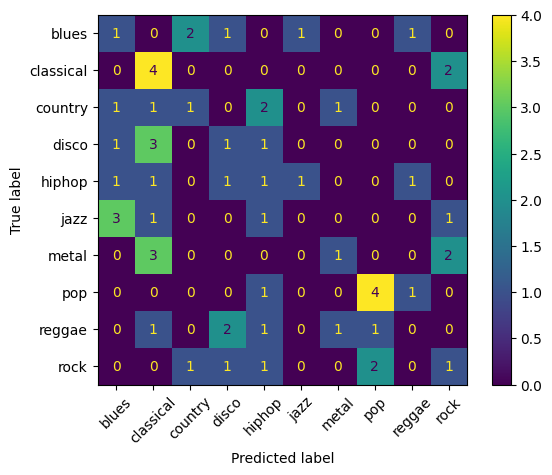

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

genre_names = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

# predictions
y_pred = clf.predict(X_test_avg)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=genre_names
)

disp.plot(xticks_rotation=45)

plt.show()

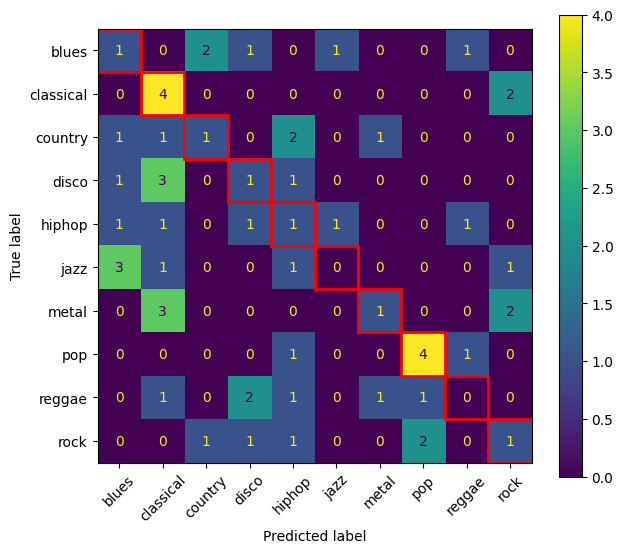

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

genre_names = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]

# predictions
y_pred = clf.predict(X_test_avg)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# figure
fig, ax = plt.subplots(figsize=(7, 6))

# display matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=genre_names
)

disp.plot(
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

# highlight diagonal
for i in range(len(cm)):
    rect = plt.Rectangle(
        (i - 0.5, i - 0.5),
        1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2
    )
    ax.add_patch(rect)

plt.show()

<Figure size 800x600 with 0 Axes>

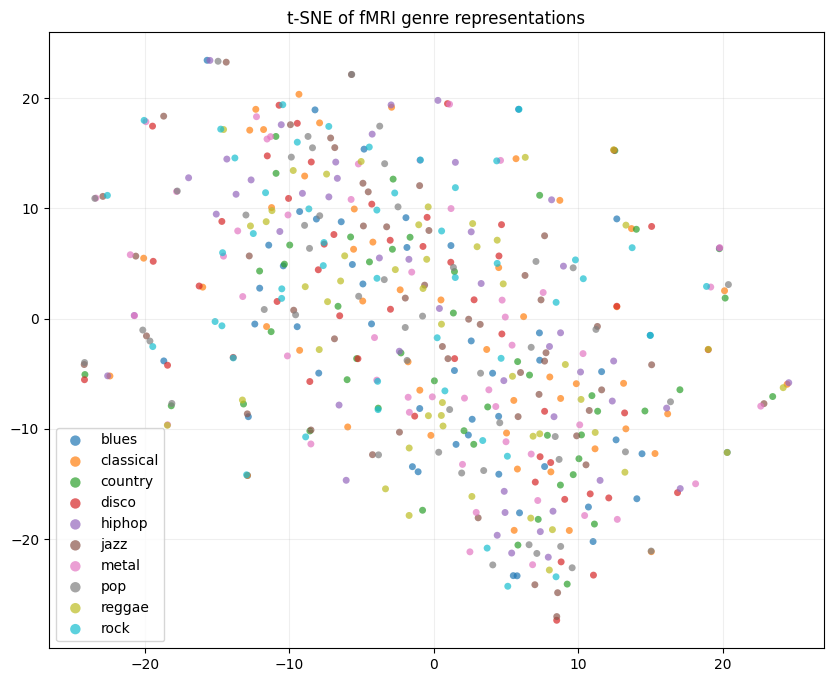

In [41]:
#TSN-E plot
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_embedded = tsne.fit_transform(X_train_avg)

plt.figure(figsize=(8, 6))

plt.figure(figsize=(10, 8))

for i, name in enumerate(genre_names):
    idx = (y_train == (i + 1))

    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        label=name,
        s=25,        # bigger points
        alpha=0.7,   # transparency
        edgecolors='none'
    )

plt.legend(markerscale=1.5, fontsize=10)
plt.title("t-SNE of fMRI genre representations")
plt.grid(True, alpha=0.2)
plt.show()

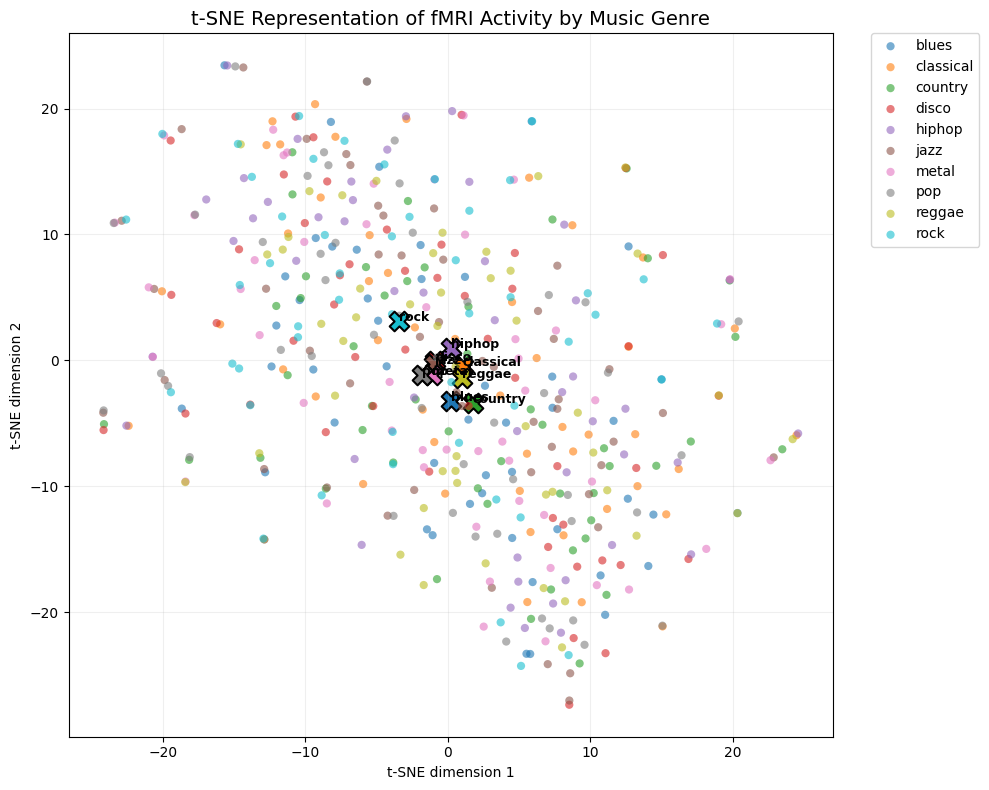

In [42]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# --- t-SNE embedding ---
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=42
)

X_embedded = tsne.fit_transform(X_train_avg)

# --- figure setup ---
plt.figure(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(genre_names)))

# --- plot each genre ---
for i, name in enumerate(genre_names):

    # IMPORTANT: adjust depending on your label encoding
    idx = (y_train == (i + 1))

    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        s=35,
        alpha=0.6,
        color=colors[i],
        label=name,
        edgecolors="none"
    )

    # --- add centroid of each genre (makes plot MUCH clearer) ---
    centroid = X_embedded[idx].mean(axis=0)

    plt.scatter(
        centroid[0],
        centroid[1],
        color=colors[i],
        s=200,
        marker="X",
        edgecolors="black",
        linewidths=1.5
    )

    plt.text(
        centroid[0],
        centroid[1],
        name,
        fontsize=9,
        weight="bold"
    )

# --- styling ---
plt.title("t-SNE Representation of fMRI Activity by Music Genre", fontsize=14)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")

plt.grid(alpha=0.2)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

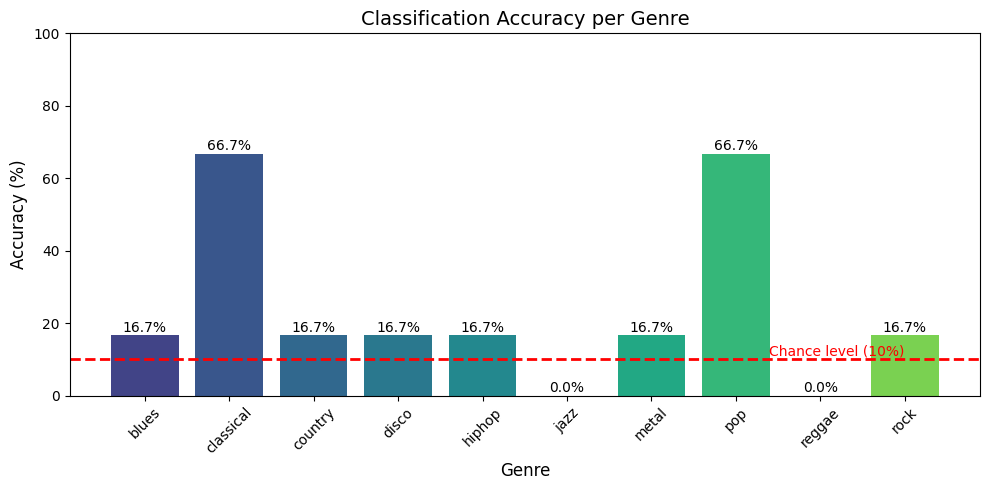

In [43]:
# --- compute accuracy per genre ---
# Get unique genres
genres = np.unique(y_test)

# Compute accuracy per genre
genre_accuracies = []

for g in genres:
    idx = (y_test == g)              # samples of this genre
    acc = np.mean(y_pred[idx] == y_test[idx]) * 100
    genre_accuracies.append(acc)
genre_accuracies = np.array(genre_accuracies)

plt.figure(figsize=(10, 5))

# Color map (clean gradient)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(genre_names)))

bars = plt.bar(genre_names, genre_accuracies, color=colors)

# Add value labels on bars
for bar, acc in zip(bars, genre_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 1,
        f"{acc:.1f}%",
        ha='center',
        fontsize=10
    )

# --- Chance level line ---
chance_level = 10
plt.axhline(y=chance_level, linestyle='--', linewidth=2, color='red')
plt.text(
    len(genre_names) - 1,
    chance_level + 1,
    "Chance level (10%)",
    color='red',
    ha='right',
    fontsize=10
)

# Labels
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Classification Accuracy per Genre", fontsize=14)

plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()